## 构建combine-net

In [ ]:
#读取pac和pd并且提取核心字段
import pandas as pd

arbor = pd.read_parquet(
    "/home/zhangbei/data/ION_varicosity/jupyter_tutorial/save_results_full9026/single_cell_connections/arbor_results_9k9k/arbor_connectivity_sparse.parquet"
)

bouton = pd.read_parquet(
    "/home/zhangbei/data/ION_varicosity/jupyter_tutorial/save_results_full9026/single_cell_connections/bouton_results_9k9k/bouton_connectivity_sparse.parquet"
)

arbor2 = arbor[["source_cell", "target_cell", "score"]].copy()
arbor2 = arbor2.rename(columns={"score": "arbor_score"})

bouton2 = bouton[["source_cell", "target_cell", "score"]].copy()
bouton2 = bouton2.rename(columns={"score": "bouton_score"})

## 读取数据

In [43]:
#读取数据
import pandas as pd

arbor_df = pd.read_parquet(
    "/home/zhangbei/data/ION_varicosity/jupyter_tutorial/save_results_full9026/single_cell_connections/arbor_results_9k9k/arbor_connectivity_sparse.parquet"
)

bouton_df = pd.read_parquet(
    "/home/zhangbei/data/ION_varicosity/jupyter_tutorial/save_results_full9026/single_cell_connections/bouton_results_9k9k/bouton_connectivity_sparse.parquet"
)

src_meta = pd.read_csv(
    "/home/zhangbei/data/ION_varicosity/jupyter_tutorial/data_9026/9k_cells_metadata_region_overwritten_from_original.csv",
    index_col=0
)

tar_meta = pd.read_csv(
    "/home/zhangbei/data/ION_varicosity/jupyter_tutorial/data_9026/9k_cells_metadata_region_overwritten_from_original.csv",
    index_col=0
)

给 source / target 挂脑区，并且检查映射情况：

In [44]:
arbor_df["source_region"] = arbor_df["source_cell"].map(src_meta["region"].to_dict())
arbor_df["target_region"] = arbor_df["target_cell"].map(tar_meta["region"].to_dict())

bouton_df["source_region"] = bouton_df["source_cell"].map(src_meta["region"].to_dict())
bouton_df["target_region"] = bouton_df["target_cell"].map(tar_meta["region"].to_dict())

print(arbor_df["source_region"].isna().sum(), "source region missing")
print(arbor_df["target_region"].isna().sum(), "target region missing")

print(bouton_df["source_region"].isna().sum(), "source region missing")
print(bouton_df["target_region"].isna().sum(), "target region missing")

arbor_df

bouton_df

0 source region missing
0 target region missing
0 source region missing
0 target region missing


,source_cell,target_cell,score,hit_count,min_dis,source_region,target_region
0,200335_002,201983_017,0.818731,1,5,CA1,CA1
1,200335_002,201983_055,11.733340,18,1,CA1,CA1
2,200335_002,201990_001,0.367879,1,25,CA1,CA1
3,200335_002,201990_003,1.679624,3,10,CA1,CA1
4,200335_002,201990_008,0.814603,2,21,CA1,CA1
...,...,...,...,...,...,...,...
604685,210711_030,210694_009,1.622174,3,6,DG,CA3
604686,210711_030,210694_010,1.142418,2,14,DG,DG
604687,210711_030,210694_011,9.097987,17,5,DG,CA3
604688,210711_030,210698_002,2.024254,3,2,DG,CA1


聚合成 arbor-net（过滤小于的score）：

In [45]:
arbor_region_net_df = (
    arbor_df
    .dropna(subset=["source_region", "target_region"])
    .groupby(["source_region", "target_region"], as_index=False)
    .agg(
        score=("score", "sum"),
        pair_count=("score", "size")
    )
    .sort_values("score", ascending=False)
)
print(arbor_region_net_df.shape)
display(arbor_region_net_df.head(10))

bouton_region_net_df = (
    bouton_df
    .dropna(subset=["source_region", "target_region"])
    .groupby(["source_region", "target_region"], as_index=False)
    .agg(        
        score=("score", "sum"),
        pair_count=("score", "size")
    )
    .sort_values("score", ascending=False)
)
print(bouton_region_net_df.shape)
display(bouton_region_net_df.head(10))

(49, 4)


,source_region,target_region,score,pair_count
0,CA1,CA1,746282.762216,180565
14,CA3,CA1,533868.585296,166573
16,CA3,CA3,395954.534593,104697
5,CA1,SUB,186649.482221,66696
4,CA1,ProS,159168.432585,48596
24,DG,DG,95432.935132,32433
40,SUB,SUB,86526.105458,26986
28,ProS,CA1,60694.354473,20924
2,CA1,CA3,50536.327222,14894
23,DG,CA3,42664.160330,24195


(49, 4)


,source_region,target_region,score,pair_count
0,CA1,CA1,432455.921053,136548
14,CA3,CA1,301878.658252,128581
16,CA3,CA3,222184.244547,82196
5,CA1,SUB,98991.025206,46620
4,CA1,ProS,85719.987473,35315
24,DG,DG,57205.929435,24358
40,SUB,SUB,44671.109938,18929
28,ProS,CA1,33249.248210,15073
2,CA1,CA3,29271.801150,11234
23,DG,CA3,24159.531630,16268


In [37]:
from pathlib import Path

out_dir = Path("/home/zhangbei/data/ION_varicosity/jupyter_tutorial/save_results_full9026/analysing_results/9k9k/a&b")
out_dir.mkdir(parents=True, exist_ok=True)

arbor_region_net_df.to_csv(
    out_dir / "9k9k_arbor_region_net_original.csv",
    index=False
)
bouton_region_net_df.to_csv(
    out_dir / "9k9k_bouton_region_net_original.csv",
    index=False
)


In [ ]:
#存为矩阵方便分析
arbor_arbor_net_matrix = arbor_region_net_df.pivot(
    index="source_region",
    columns="target_region",
    values="score"
).fillna(0)

# arbor_net_matrix.to_csv(
#     "/home/zhangbei/data/ION_varicosity/jupyter_tutorial/save_results_full9026/analysing_results/9k9k/a&b/9k9k_combined_arbor_net_matrix_original.csv"
# )

arbor_arbor_net_matrix
print(arbor_arbor_net_matrix.shape)

(7, 7)


画图，9k9k

In [40]:
import numpy as np
import pandas as pd

# =========================
# 1. 读取 arbor-level 结果
# =========================
arbor_net_df = pd.read_csv(
    "/home/zhangbei/data/ION_varicosity/jupyter_tutorial/save_results_full9026/analysing_results/9k9k/a&b/9k9k_arbor_region_net_original.csv"
)
bouton_net_df = pd.read_csv(
    "/home/zhangbei/data/ION_varicosity/jupyter_tutorial/save_results_full9026/analysing_results/9k9k/a&b/9k9k_bouton_region_net_original.csv"
)
# =========================
# 2. 计算 mean_positive_score
# =========================
arbor_net_df["mean_positive_score"] = (
    arbor_net_df["score"] / arbor_net_df["pair_count"]
)
bouton_net_df["mean_positive_score"] = (
    bouton_net_df["score"] / bouton_net_df["pair_count"]
)
# =========================
# 3. 去掉不想解释的标签
# =========================
drop_labels = ["fiber tracts", "unknow"]

arbor_net_df = arbor_net_df[
    ~arbor_net_df["source_region"].isin(drop_labels)
    & ~arbor_net_df["target_region"].isin(drop_labels)
].copy()

bouton_net_df = bouton_net_df[
    ~bouton_net_df["source_region"].isin(drop_labels)
    & ~bouton_net_df["target_region"].isin(drop_labels)
].copy()
# # =========================
# # 4. 按 mean score 阈值过滤
# # 低于阈值的脑区对置为 0
# # =========================
# mean_score_threshold = 1.0

# filtered_pair_count = (
#     (arbor_net_df["mean_positive_score"] > 0)
#     & (arbor_net_df["mean_positive_score"] < mean_score_threshold)
# ).sum()

# kept_pair_count = (
#     arbor_net_df["mean_positive_score"] >= mean_score_threshold
# ).sum()

# print(f"mean score threshold: {mean_score_threshold}")
# print(f"filtered arbor-pair count: {filtered_pair_count}")
# print(f"kept arbor-pair count: {kept_pair_count}")

# arbor_net_df.loc[
#     arbor_net_df["mean_positive_score"] < mean_score_threshold,
#     "mean_positive_score"
# ] = 0

# =========================
# 5. pivot 成 mean 矩阵
# =========================
arbor2arbor_mean_mat = (
    arbor_net_df.pivot(
        index="source_region",
        columns="target_region",
        values="mean_positive_score"
    )
    .fillna(0)
)
bouton2bouton_mean_mat = (
    bouton_net_df.pivot(
        index="source_region",
        columns="target_region",
        values="mean_positive_score"
    )
    .fillna(0)
)
print(arbor2arbor_mean_mat.shape)
display(arbor2arbor_mean_mat.iloc[:5, :8])

print(bouton2bouton_mean_mat.shape)
display(bouton2bouton_mean_mat.iloc[:5, :8])

# =========================
# 6. 保存中间结果
# =========================
arbor2arbor_mean_mat.to_csv(
    "/home/zhangbei/data/ION_varicosity/jupyter_tutorial/save_results_full9026/analysing_results/9k9k/a&b/9k9k_arbor_net_mean_positive_matrix_original.csv"
)

bouton2bouton_mean_mat.to_csv(
    "/home/zhangbei/data/ION_varicosity/jupyter_tutorial/save_results_full9026/analysing_results/9k9k/a&b/9k9k_bouton_net_mean_positive_matrix_original.csv"
)

arbor_net_df.to_csv(
    "/home/zhangbei/data/ION_varicosity/jupyter_tutorial/save_results_full9026/analysing_results/9k9k/a&b/9k9k_arbor_net_mean_positive_longtable_original.csv",
    index=False
)

bouton_net_df.to_csv(
    "/home/zhangbei/data/ION_varicosity/jupyter_tutorial/save_results_full9026/analysing_results/9k9k/a&b/9k9k_bouton_net_mean_positive_longtable_original.csv",
    index=False
)

(7, 7)


target_region,CA1,CA2,CA3,DG,ProS,SUB,SUBr
source_region,,,,,,,
CA1,4.133042,3.692875,3.393066,2.528123,3.275340,2.798511,1.975399
CA2,3.913552,4.515922,4.156060,1.771250,2.807660,1.724871,2.662212
CA3,3.205013,2.931206,3.781909,2.429753,2.625458,2.144254,1.736213
DG,2.381609,1.513172,1.763346,2.942464,2.320480,2.273847,2.415332
ProS,2.900705,1.212283,1.740101,1.888221,3.679371,2.923880,2.134123


(7, 7)


target_region,CA1,CA2,CA3,DG,ProS,SUB,SUBr
source_region,,,,,,,
CA1,3.167062,2.890588,2.605644,2.071583,2.427297,2.123360,1.594160
CA2,2.979722,3.279235,3.054844,1.564839,2.109351,1.375697,1.928417
CA3,2.347770,2.150071,2.703103,1.915471,1.943813,1.688227,1.058232
DG,1.828237,1.332622,1.485095,2.348548,1.802950,1.815371,2.083488
ProS,2.205881,0.962520,1.524701,1.540763,2.659025,2.241044,1.735145


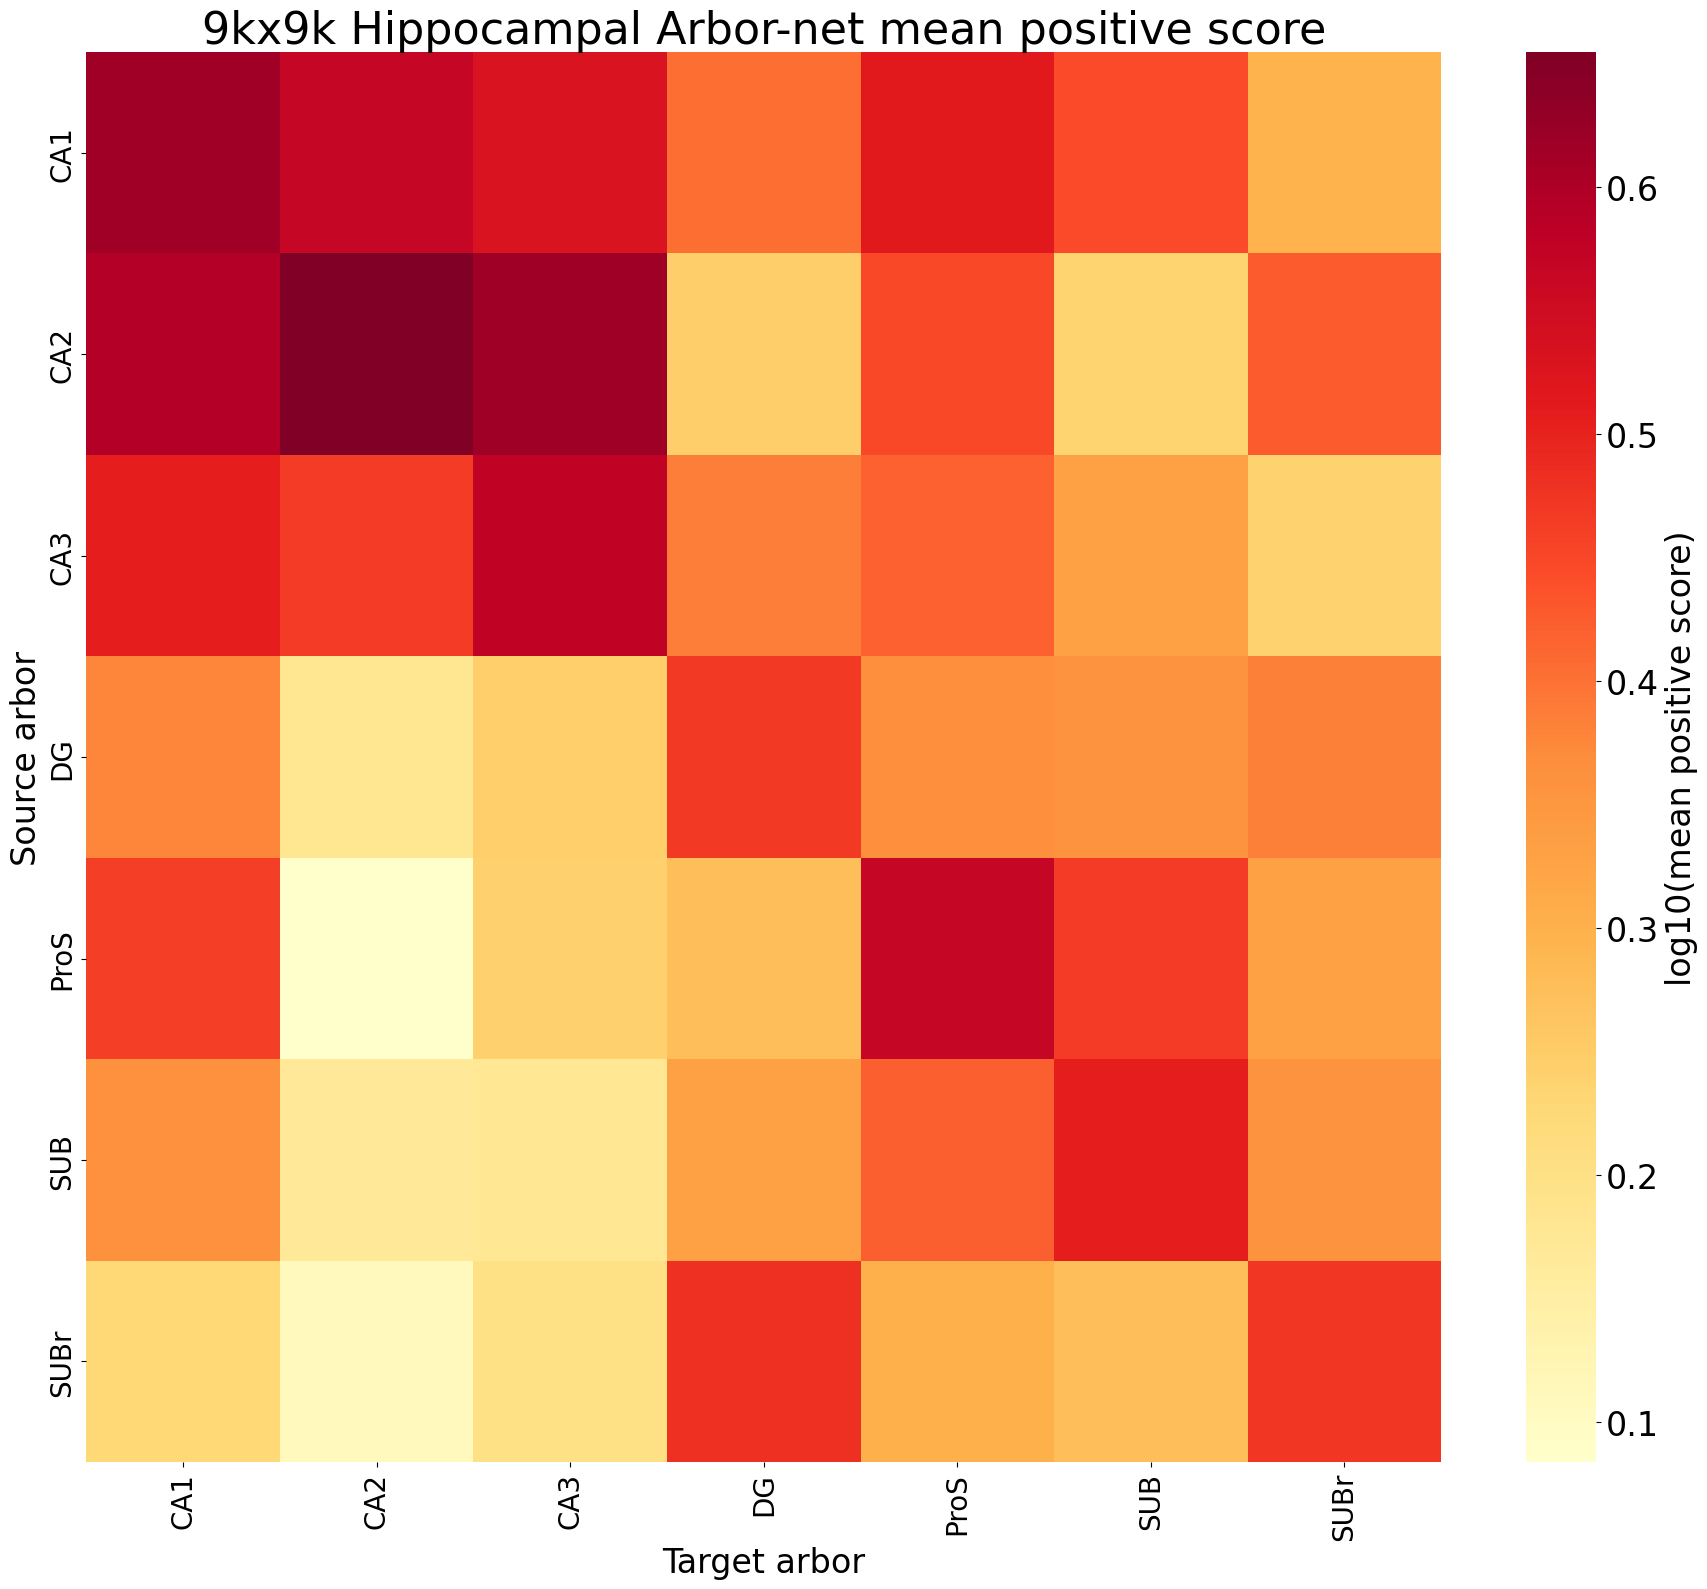

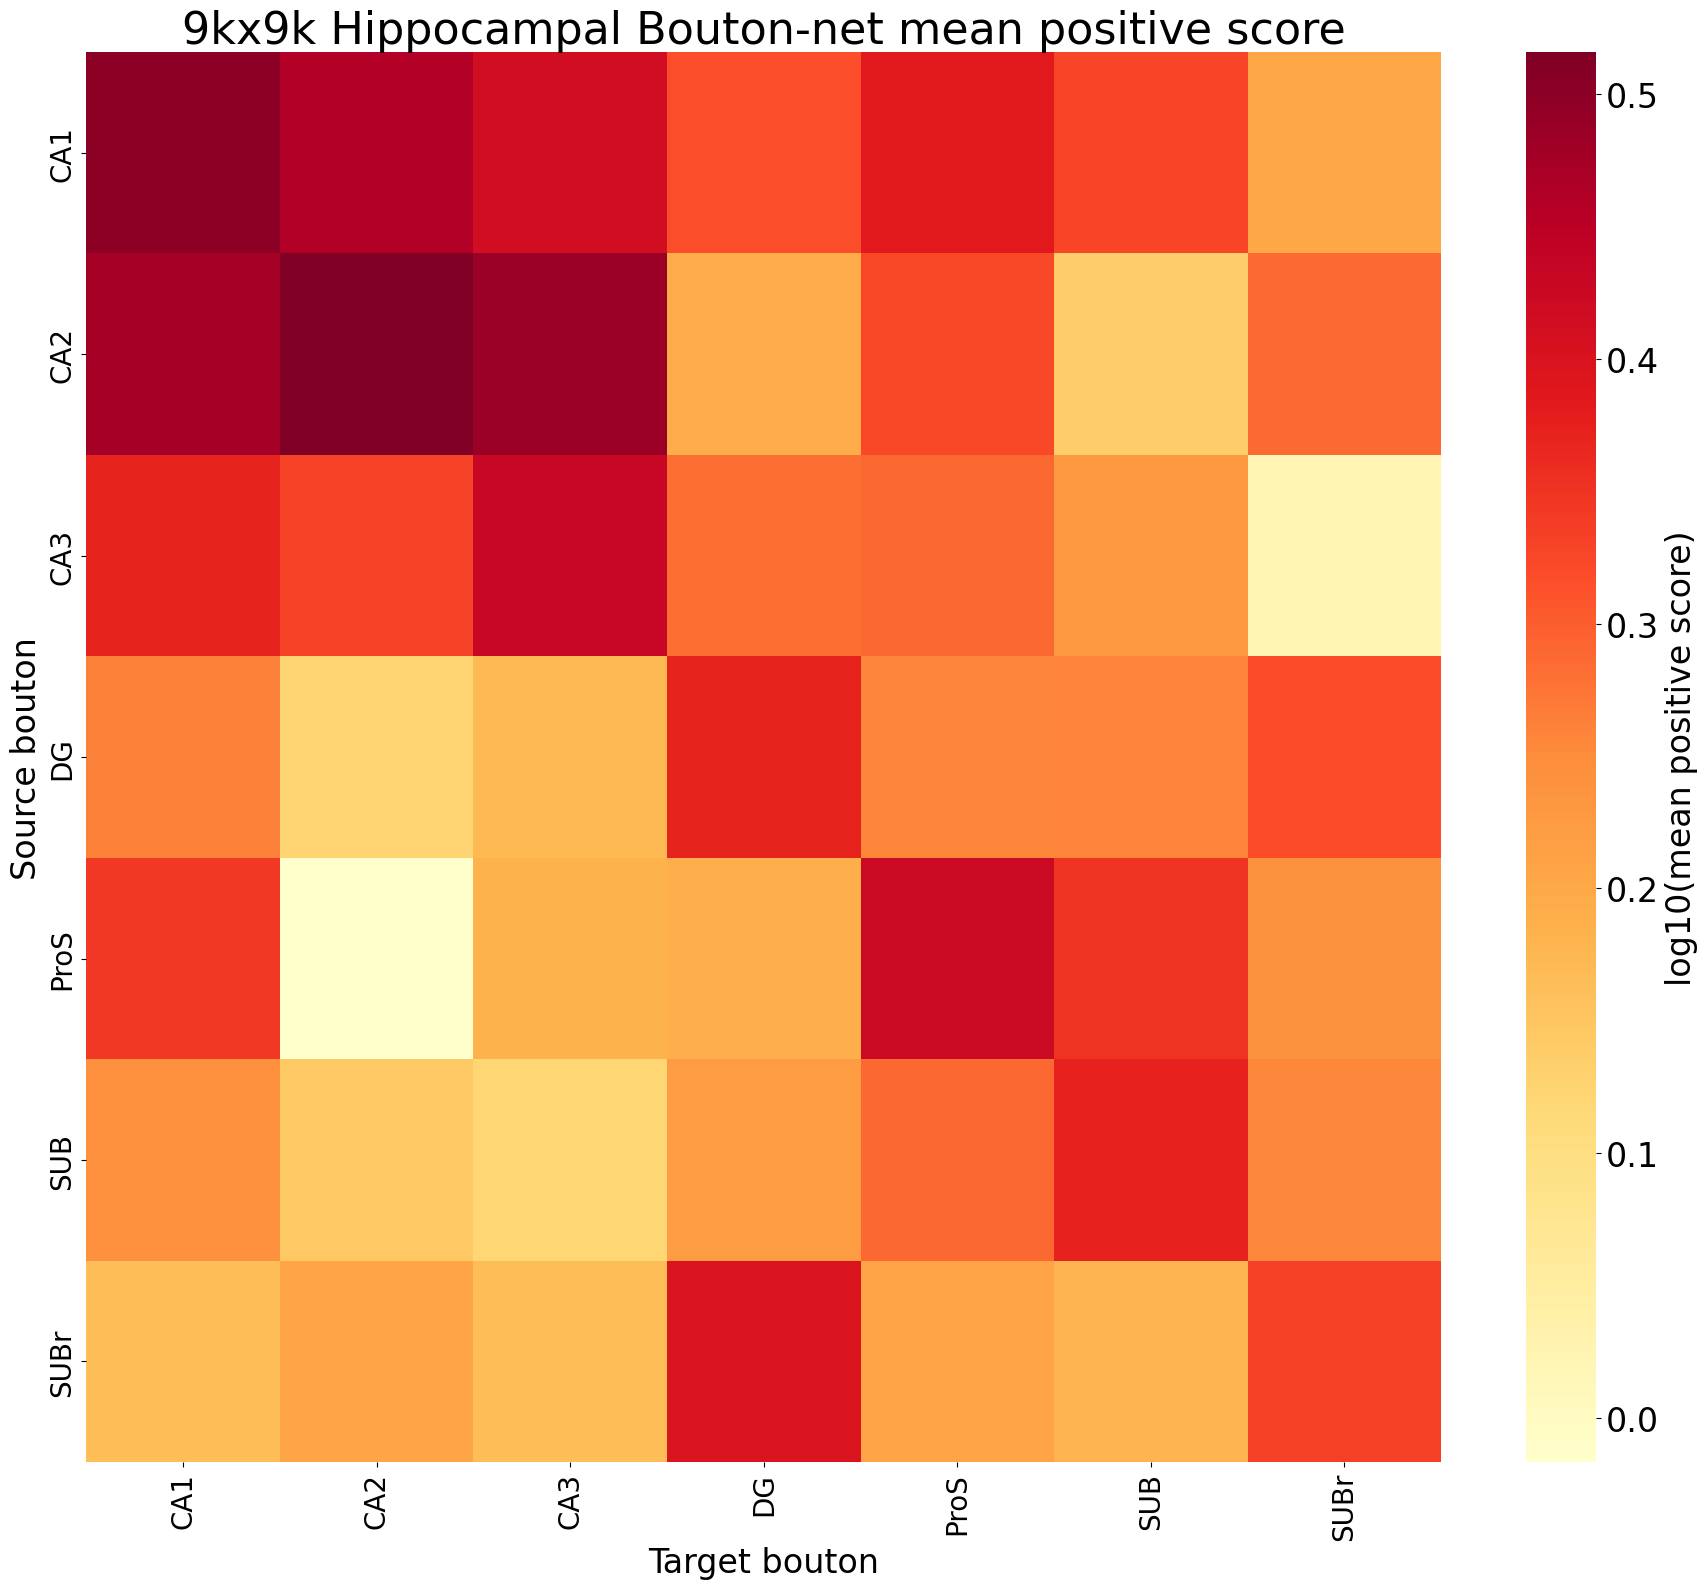

arbor matrix shape: (7, 7)
bouton matrix shape: (7, 7)


In [42]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

save_dir = "/home/zhangbei/data/ION_varicosity/jupyter_tutorial/save_results_full9026/analysing_results/9k9k/a&b"

# =========================
# 1. 读取 longtable
# =========================
arbor_net_df = pd.read_csv(
    os.path.join(save_dir, "9k9k_arbor_net_mean_positive_longtable_original.csv")
)

bouton_net_df = pd.read_csv(
    os.path.join(save_dir, "9k9k_bouton_net_mean_positive_longtable_original.csv")
)

# =========================
# 2. longtable -> matrix
# =========================
arbor2arbor_mean_mat = (
    arbor_net_df
    .pivot(index="source_region", columns="target_region", values="mean_positive_score")
    .fillna(0)
)

bouton2bouton_mean_mat = (
    bouton_net_df
    .pivot(index="source_region", columns="target_region", values="mean_positive_score")
    .fillna(0)
)

# =========================
# 3. 对非零值做 log10
# =========================
def log10_positive_matrix(mat):
    v = mat.values.copy()
    used_mask = v > 0
    v[used_mask] = np.log10(v[used_mask])

    return pd.DataFrame(
        v,
        index=mat.index,
        columns=mat.columns
    )

arbor2arbor_mean_scaled = log10_positive_matrix(arbor2arbor_mean_mat)
bouton2bouton_mean_scaled = log10_positive_matrix(bouton2bouton_mean_mat)

# =========================
# 4. 画热力图函数
# =========================
def plot_heatmap(mat, title, xlabel, ylabel, save_path):
    plt.figure(figsize=(18, 16))

    ax = sns.heatmap(
        mat,
        cmap="YlOrRd",
        cbar_kws={"label": "log10(mean positive score)"}
    )

    plt.title(title, fontsize=32)
    plt.xlabel(xlabel, fontsize=24)
    plt.ylabel(ylabel, fontsize=24)

    cbar = ax.collections[0].colorbar
    cbar.ax.tick_params(labelsize=24)
    cbar.set_label("log10(mean positive score)", fontsize=24)

    plt.xticks(fontsize=20, rotation=90)
    plt.yticks(fontsize=20)

    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

# =========================
# 5. arbor heatmap
# =========================
plot_heatmap(
    arbor2arbor_mean_scaled,
    title="9kx9k Hippocampal Arbor-net mean positive score",
    xlabel="Target arbor",
    ylabel="Source arbor",
    save_path=os.path.join(save_dir, "9k9k_arbor2arbor_mean_heatmap_original.png")
)

# =========================
# 6. bouton heatmap
# =========================
plot_heatmap(
    bouton2bouton_mean_scaled,
    title="9kx9k Hippocampal Bouton-net mean positive score",
    xlabel="Target bouton",
    ylabel="Source bouton",
    save_path=os.path.join(save_dir, "9k9k_bouton2bouton_mean_heatmap_original.png")
)

print("arbor matrix shape:", arbor2arbor_mean_mat.shape)
print("bouton matrix shape:", bouton2bouton_mean_mat.shape)


海马内部热力图

海马全脑热力图

(7, 177)


,PA,BMA,CLA,EPv,EPd,BLA,LA,PAR
source_region,,,,,,,,
CA1,1.337424,1.196850,1.436479,1.443528,1.321012,1.187729,1.087003,1.658807
CA2,1.747591,2.107296,1.998297,0.191446,0.000000,0.183940,0.000000,2.400962
CA3,1.239945,1.284426,0.000000,1.159358,0.000000,0.000000,0.000000,0.815894
DG,1.984690,0.443460,0.000000,0.000000,0.000000,0.000000,0.000000,1.502974
ProS,1.342132,1.169858,1.219762,1.547221,1.444106,1.185897,1.119958,1.691143


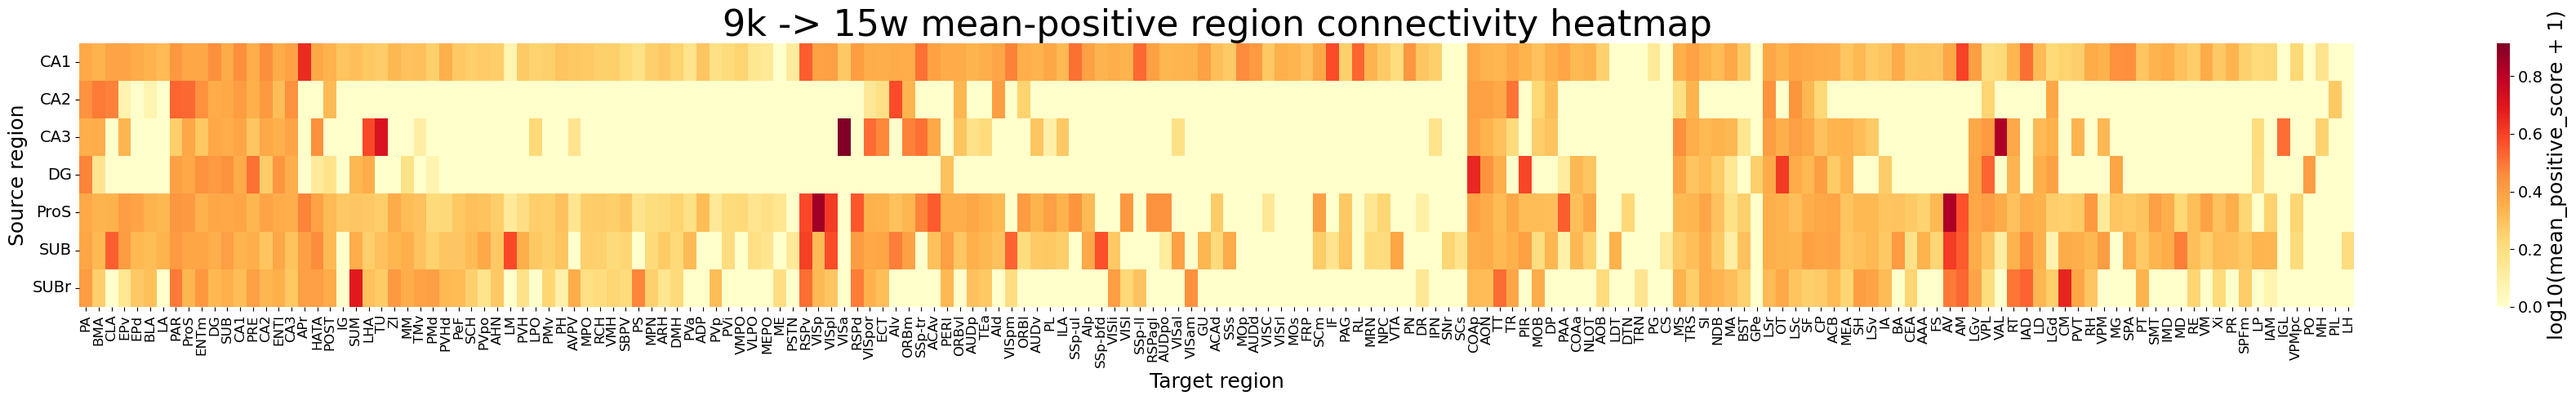

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json


def sort_targets_by_super_structure(
    df,
    map_path="/home/zhangbei/data/ION_varicosity/jupyter_tutorial/data_9026/super_arbor_map.json"
):
    with open(map_path, "r") as f:
        super_map = json.load(f)

    super_order = [f"CA{i}" for i in range(1, 14)]
    super_rank_map = {sid: i for i, sid in enumerate(super_order)}

    target_strength = df.sum(axis=0)

    target_sort_df = pd.DataFrame({
        "target_arbor": df.columns.astype(str)
    })

    target_sort_df["super_id"] = target_sort_df["target_arbor"].map(
        lambda x: super_map.get(x, {}).get("super_id", "ZZZ")
    )
    target_sort_df["super_rank"] = target_sort_df["super_id"].map(
        lambda x: super_rank_map.get(x, len(super_order))
    )
    target_sort_df["strength"] = target_sort_df["target_arbor"].map(target_strength)

    target_order = (
        target_sort_df
        .sort_values(
            ["super_rank", "strength", "target_arbor"],
            ascending=[True, False, True]
        )["target_arbor"]
        .tolist()
    )

    return df.loc[:, target_order], target_sort_df


# =========================
# 1. 直接读取 mean score 中间矩阵
# =========================
arbor_mat = pd.read_csv(
    "/home/zhangbei/data/ION_varicosity/jupyter_tutorial/save_results_full9026/analysing_results/9k9k/a&b/9k9k_combined_arbor_net_mean_positive_matrix_original.csv",
    index_col=0
)

print(arbor_mat.shape)
display(arbor_mat.iloc[:5, :8])

# =========================
# 2. 按 target 总强度排序
# =========================
arbor_mat, target_sort_df = sort_targets_by_super_structure(arbor_mat)

# =========================
# 3. 画热力图
# =========================
plot_mat = np.log10(arbor_mat + 1)

plt.figure(figsize=(36, 5))
ax = sns.heatmap(
    plot_mat,
    cmap="YlOrRd",
    vmin=0,
    cbar_kws={"label": "log10(mean_positive_score + 1)"}
)

ax.set_title("9k -> 15w mean-positive arbor connectivity heatmap", fontsize=32)
ax.set_xlabel("Target arbor", fontsize=18)
ax.set_ylabel("Source arbor", fontsize=18)

step = 1
xticks = np.arange(plot_mat.shape[1]) + 0.5
ax.set_xticks(xticks[::step])
ax.set_xticklabels(plot_mat.columns[::step], rotation=90, fontsize=12)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=14)

cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=14)
cbar.set_label("log10(mean_positive_score + 1)", fontsize=18)

plt.tight_layout()
plt.savefig(
    "/home/zhangbei/data/ION_varicosity/jupyter_tutorial/save_results_full9026/analysing_results/9k9k/a&b/9k9k_combined_arbor_net_mean_positive_heatmap_original.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


(7, 177)


,AAA,ACAd,ACAv,ACB,ADP,AHN,AId,AIp
source_region,,,,,,,,
CA1,0.0,1.016433,1.469483,1.255384,0.000000,0.0,1.405529,1.479763
CA2,0.0,0.000000,0.000000,0.000000,0.000000,0.0,1.537645,0.000000
CA3,0.0,0.000000,1.370680,1.165521,0.000000,0.0,0.000000,0.000000
DG,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000
ProS,0.0,0.000000,2.527387,1.415894,1.061759,0.0,1.112260,1.090556


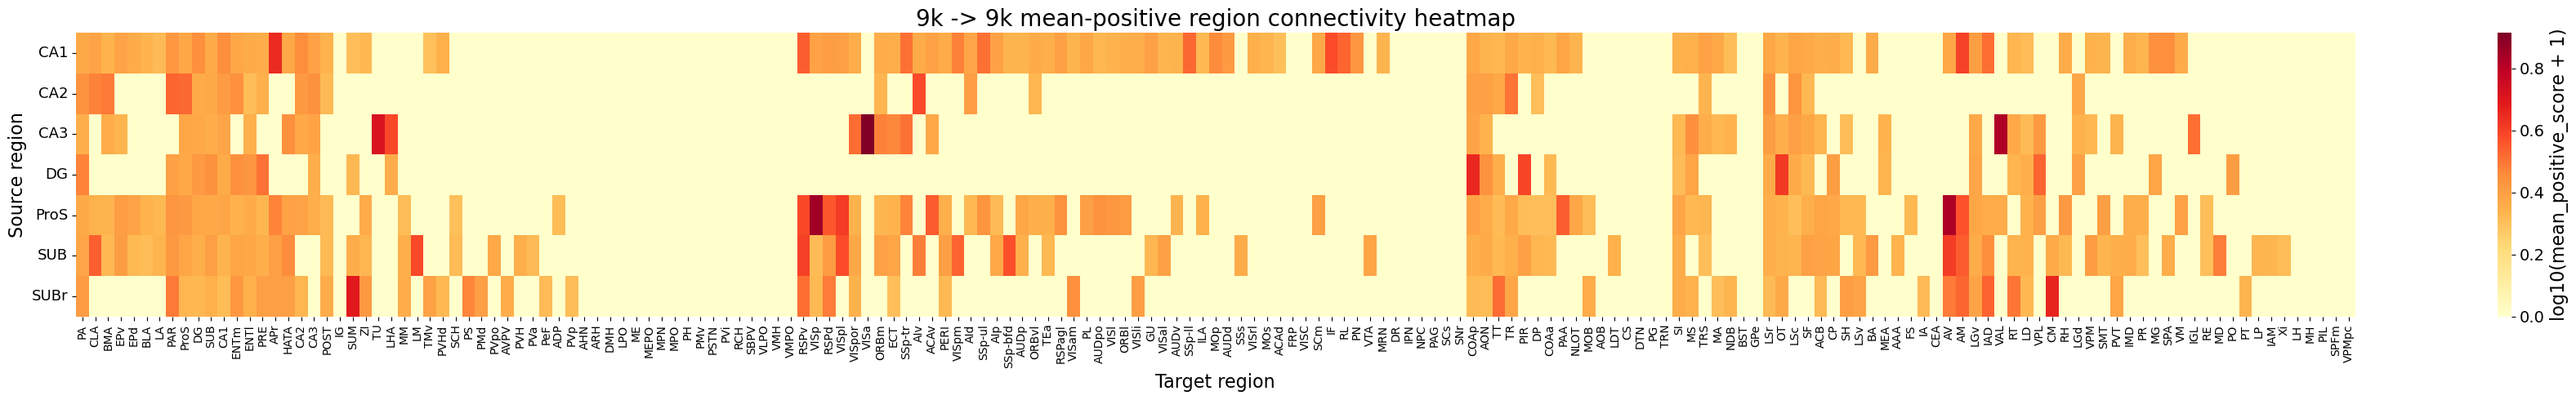

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json

def sort_targets_by_super_structure(
    df,
    map_path="/home/zhangbei/data/ION_varicosity/jupyter_tutorial/data_9026/super_arbor_map.json"
):
    with open(map_path, "r") as f:
        super_map = json.load(f)

    super_order = [f"CA{i}" for i in range(1, 14)]
    super_rank_map = {sid: i for i, sid in enumerate(super_order)}

    target_strength = df.sum(axis=0)

    target_sort_df = pd.DataFrame({
        "target_arbor": df.columns.astype(str)
    })
    target_sort_df["super_id"] = target_sort_df["target_arbor"].map(
        lambda x: super_map.get(x, {}).get("super_id", "ZZZ")
    )
    target_sort_df["super_rank"] = target_sort_df["super_id"].map(
        lambda x: super_rank_map.get(x, len(super_order))
    )
    target_sort_df["strength"] = target_sort_df["target_arbor"].map(target_strength)

    target_order = (
        target_sort_df
        .sort_values(
            ["super_rank", "strength", "target_arbor"],
            ascending=[True, False, True]
        )["target_arbor"]
        .tolist()
    )

    return df.loc[:, target_order], target_sort_df

# =========================
# 1. 读取已经存好的 arbor-level 结果
# =========================
arbor_net_df = pd.read_csv(
    "/home/zhangbei/data/ION_varicosity/jupyter_tutorial/save_results_full9026/analysing_results/9k9k/a&b/9k9k_combined_arbor_net_original.csv"
)

# =========================
# 2. 从 sum 和 pair_count 直接得到 mean_positive_score
# =========================
arbor_net_df["mean_positive_score"] = arbor_net_df["score"] / arbor_net_df["pair_count"]

# =========================
# 3. 去掉不想解释的标签
# =========================
drop_labels = ["fiber tracts", "unknow"]

arbor_net_df = arbor_net_df[
    ~arbor_net_df["source_arbor"].isin(drop_labels) &
    ~arbor_net_df["target_arbor"].isin(drop_labels)
].copy()

# =========================
# 4. pivot
# =========================
arbor_mat = (
    arbor_net_df.pivot(
        index="source_arbor",
        columns="target_arbor",
        values="mean_positive_score"
    )
    .fillna(0)
)

print(arbor_mat.shape)
display(arbor_mat.iloc[:5, :8])

# =========================
# 5. 按 target 总强度排序
# =========================
arbor_mat, target_sort_df = sort_targets_by_super_structure(arbor_mat)

# =========================
# 6. 保存 mean 矩阵
# =========================
arbor_mat.to_csv(
    "/home/zhangbei/data/ION_varicosity/jupyter_tutorial/save_results_full9026/analysing_results/9k9k/a&b/9k9k_combined_arbor_net_mean_positive_matrix_original.csv"
)

# 也顺手存 long table
arbor_net_df.to_csv(
    "/home/zhangbei/data/ION_varicosity/jupyter_tutorial/save_results_full9026/analysing_results/9k9k/a&b/9k9k_combined_arbor_net_mean_positive_longtable_original.csv",
    index=False
)

# =========================
# 7. 画热力图
# =========================
plot_mat = np.log10(arbor_mat + 1)

plt.figure(figsize=(36, 5))
ax = sns.heatmap(
    plot_mat,
    cmap="YlOrRd",
    vmin=0,
    cbar_kws={"label": "log10(mean_positive_score + 1)"}
)

ax.set_title("9k -> 15w mean-positive arbor connectivity heatmap", fontsize=20)
ax.set_xlabel("Target arbor", fontsize=16)
ax.set_ylabel("Source arbor", fontsize=16)

step = 6
xticks = np.arange(plot_mat.shape[1]) + 0.5
ax.set_xticks(xticks[::step])
ax.set_xticklabels(plot_mat.columns[::step], rotation=90, fontsize=10)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=13)

cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=14)
cbar.set_label("log10(mean_positive_score + 1)", fontsize=16)

plt.tight_layout()
plt.savefig(
    "/home/zhangbei/data/ION_varicosity/jupyter_tutorial/save_results_full9026/analysing_results/9k9k/a&b/9k9k_combined_arbor_net_mean_positive_heatmap_original.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


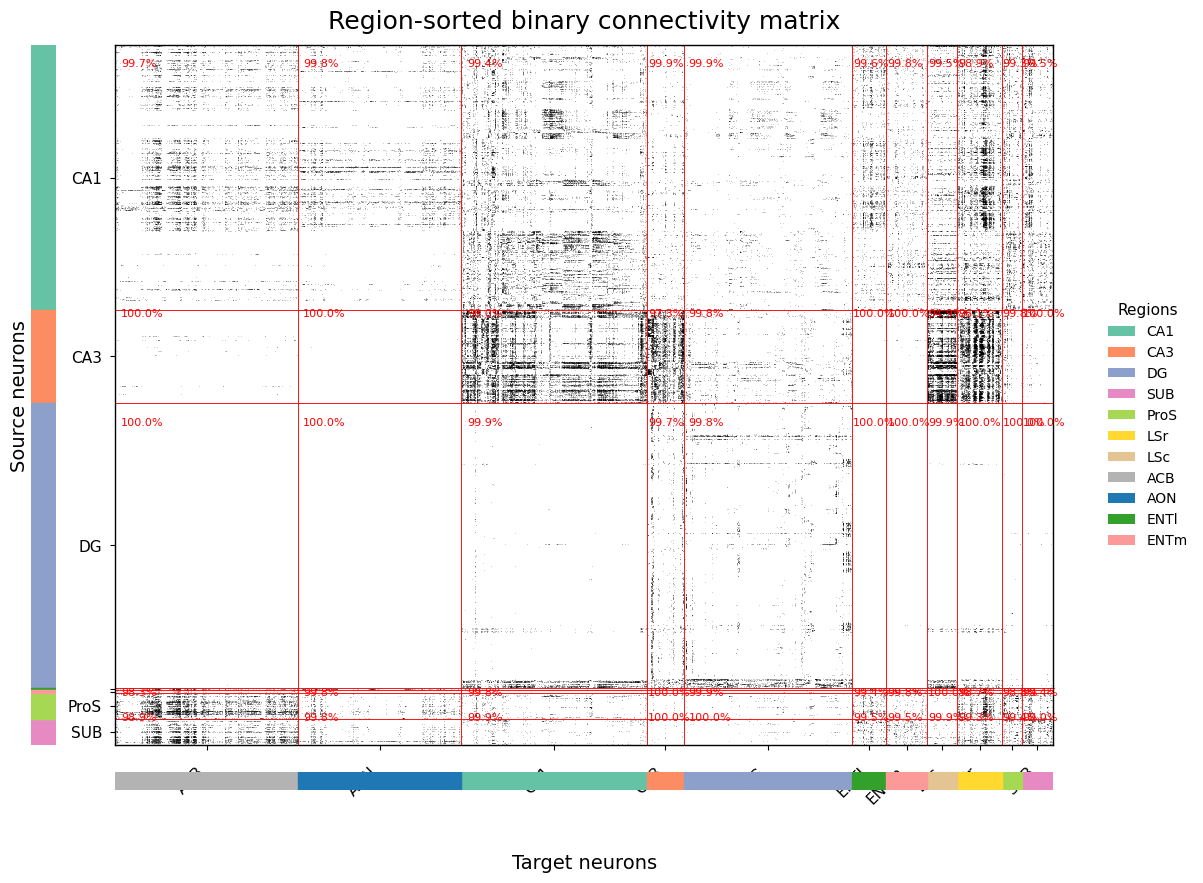

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, Patch

# =========================
# 1. 输入文件
# =========================
score_path = "/home/zhangbei/data/ION_varicosity/jupyter_tutorial/save_results_full6554/single_cell_connections/arbor_results_pac_6kx15w/arbor_connectivity_sparse.parquet"
# bouton 的话改成：
# score_path = "/home/zhangbei/data/ION_varicosity/jupyter_tutorial/save_results_full6554/single_cell_connections/bouton_results_pb_6kx15w/bouton_connectivity_sparse.parquet"

src_meta_path = "/home/zhangbei/data/ION_varicosity/jupyter_tutorial/data_6554/6554_cells_metadata.csv"
tar_meta_path = "/home/zhangbei/data/ION_varicosity/jupyter_tutorial/data_6554/15w_cells_metadata.csv"

save_path = "/home/zhangbei/data/ION_varicosity/jupyter_tutorial/analysing_results/arbor_sorted_binary_matrix_clean.png"

# =========================
# 2. 读数据
# =========================
df = pd.read_parquet(score_path)
src_meta = pd.read_csv(src_meta_path, index_col=0)
tar_meta = pd.read_csv(tar_meta_path, index_col=0)

df["source_arbor"] = df["source_cell"].map(src_meta["arbor"].to_dict())
df["target_arbor"] = df["target_cell"].map(tar_meta["arbor"].to_dict())

df = df.dropna(subset=["source_arbor", "target_arbor"]).copy()
df["conn"] = 1

# =========================
# 3. 选择主要脑区
# =========================
keep_arbors = [
    "CA1", "CA3", "DG", "SUB", "ProS",
    "LSr", "LSc", "ACB", "AON", "ENTl", "ENTm"
]

df = df[
    df["source_arbor"].isin(keep_arbors) &
    df["target_arbor"].isin(keep_arbors)
].copy()

# =========================
# 4. 建立 source / target 排序索引
# =========================
src_order_df = (
    df[["source_cell", "source_arbor"]]
    .drop_duplicates()
    .sort_values(["source_arbor", "source_cell"])
    .reset_index(drop=True)
)
src_order_df["row_idx"] = np.arange(len(src_order_df))

tar_order_df = (
    df[["target_cell", "target_arbor"]]
    .drop_duplicates()
    .sort_values(["target_arbor", "target_cell"])
    .reset_index(drop=True)
)
tar_order_df["col_idx"] = np.arange(len(tar_order_df))
ß
df = df.merge(src_order_df[["source_cell", "row_idx"]], on="source_cell", how="left")
df = df.merge(tar_order_df[["target_cell", "col_idx"]], on="target_cell", how="left")

# =========================
# 5. 脑区 block 信息
# =========================
src_blocks = (
    src_order_df.groupby("source_arbor")
    .agg(start=("row_idx", "min"), end=("row_idx", "max"), n=("row_idx", "size"))
    .reset_index()
)

tar_blocks = (
    tar_order_df.groupby("target_arbor")
    .agg(start=("col_idx", "min"), end=("col_idx", "max"), n=("col_idx", "size"))
    .reset_index()
)

# 固定脑区顺序
src_blocks["source_arbor"] = pd.Categorical(src_blocks["source_arbor"], categories=keep_arbors, ordered=True)
tar_blocks["target_arbor"] = pd.Categorical(tar_blocks["target_arbor"], categories=keep_arbors, ordered=True)
src_blocks = src_blocks.sort_values("source_arbor").reset_index(drop=True)
tar_blocks = tar_blocks.sort_values("target_arbor").reset_index(drop=True)

# =========================
# 6. 脑区颜色
# =========================
arbor_colors = {
    "CA1": "#66c2a5",
    "CA3": "#fc8d62",
    "DG": "#8da0cb",
    "SUB": "#e78ac3",
    "ProS": "#a6d854",
    "LSr": "#ffd92f",
    "LSc": "#e5c494",
    "ACB": "#b3b3b3",
    "AON": "#1f78b4",
    "ENTl": "#33a02c",
    "ENTm": "#fb9a99",
}

# =========================
# 7. 标签显示阈值
# 小于阈值的脑区不在主轴显示文字，避免重叠
# =========================
min_src_label_cells = 120
min_tar_label_cells = 250

src_tick_pos = src_blocks["start"] + src_blocks["n"] / 2
src_tick_labels = [
    r["source_arbor"] if r["n"] >= min_src_label_cells else ""
    for _, r in src_blocks.iterrows()
]

tar_tick_pos = tar_blocks["start"] + tar_blocks["n"] / 2
tar_tick_labels = [
    r["target_arbor"] if r["n"] >= min_tar_label_cells else ""
    for _, r in tar_blocks.iterrows()
]

# =========================
# 8. 作图
# =========================
fig = plt.figure(figsize=(14, 10))

# 主矩阵
ax = fig.add_axes([0.18, 0.18, 0.67, 0.70])

# 左侧颜色条
ax_left = fig.add_axes([0.12, 0.18, 0.018, 0.70])

# 下侧颜色条
ax_bottom = fig.add_axes([0.18, 0.135, 0.67, 0.018])

# 主矩阵散点
ax.scatter(
    df["col_idx"],
    df["row_idx"],
    s=0.08,
    c="black",
    alpha=0.8,
    linewidths=0
)

ax.set_xlim(-1, len(tar_order_df))
ax.set_ylim(len(src_order_df), -1)

ax.set_title("arbor-sorted binary connectivity matrix", fontsize=18, pad=12)
ax.set_xlabel("Target neurons", fontsize=14, labelpad=34)
ax.set_ylabel("Source neurons", fontsize=14, labelpad=28)

# y轴标签
ax.set_yticks(src_tick_pos)
ax.set_yticklabels(src_tick_labels, fontsize=11)
ax.tick_params(axis="y", pad=6)

# x轴标签
ax.set_xticks(tar_tick_pos)
ax.set_xticklabels(tar_tick_labels, rotation=45, ha="right", fontsize=11)
ax.tick_params(axis="x", pad=10)

for spine in ax.spines.values():
    spine.set_linewidth(1.0)

ax.set_facecolor("white")

# 左侧 source 脑区颜色条
for _, r in src_blocks.iterrows():
    ax_left.add_patch(Rectangle(
        (0, r["start"]),
        1,
        r["n"],
        color=arbor_colors.get(r["source_arbor"], "lightgray")
    ))
ax_left.set_xlim(0, 1)
ax_left.set_ylim(len(src_order_df), 0)
ax_left.axis("off")

# 下侧 target 脑区颜色条
for _, r in tar_blocks.iterrows():
    ax_bottom.add_patch(Rectangle(
        (r["start"], 0),
        r["n"],
        1,
        color=arbor_colors.get(r["target_arbor"], "lightgray")
    ))
ax_bottom.set_xlim(0, len(tar_order_df))
ax_bottom.set_ylim(0, 1)
ax_bottom.axis("off")

# =========================
# 9. 红框和 sparsity
# =========================
for _, sr in src_blocks.iterrows():
    for _, tr in tar_blocks.iterrows():
        block_df = df[
            (df["source_arbor"] == sr["source_arbor"]) &
            (df["target_arbor"] == tr["target_arbor"])
        ]

        total_possible = sr["n"] * tr["n"]
        n_conn = len(block_df)

        if total_possible == 0:
            continue

        sparsity = 100 * (1 - n_conn / total_possible)

        ax.add_patch(Rectangle(
            (tr["start"], sr["start"]),
            tr["n"],
            sr["n"],
            fill=False,
            edgecolor="red",
            linewidth=0.6,
            alpha=0.8
        ))

        # 只给较大的 block 标数字
        if sr["n"] > 25 and tr["n"] > 25:
            ax.text(
                tr["start"] + tr["n"] * 0.03,
                sr["start"] + sr["n"] * 0.08,
                f"{sparsity:.1f}%",
                color="red",
                fontsize=8
            )

# =========================
# 10. 图例：所有脑区名称都放这里，避免轴上挤
# =========================
legend_handles = [
    Patch(facecolor=arbor_colors[r], edgecolor="none", label=r)
    for r in keep_arbors if r in arbor_colors
]

fig.legend(
    handles=legend_handles,
    loc="center left",
    bbox_to_anchor=(0.88, 0.5),
    frameon=False,
    title="arbors",
    fontsize=10,
    title_fontsize=11
)

# =========================
# 11. 保存 + 显示
# =========================

plt.show()
